In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (1797, 64)
Target shape: (1797,)


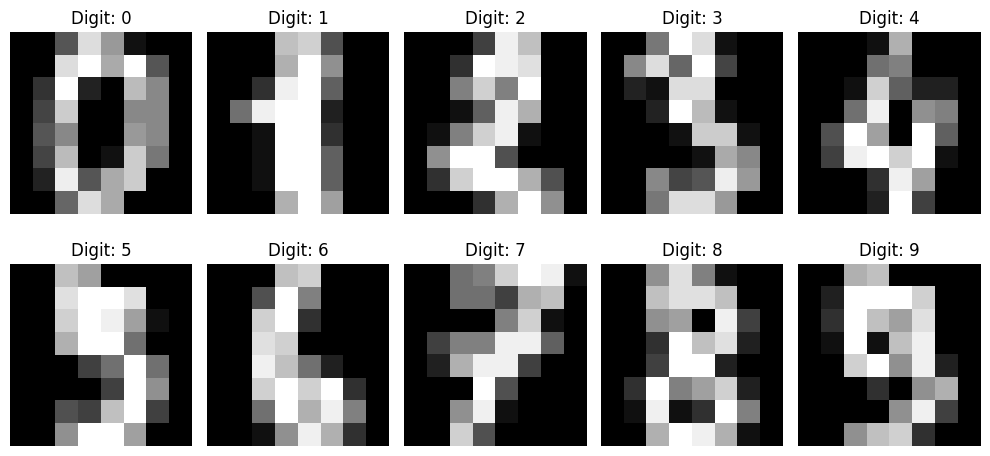

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, image, label in zip(axes.ravel(), digits.images[:10], y[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (1797, 64)
Scaled shape: (1797, 64)


In [6]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (1797, 64)
PCA shape: (1797, 2)


In [7]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.12033916 0.09561054]

Total explained variance:
0.21594970500832789


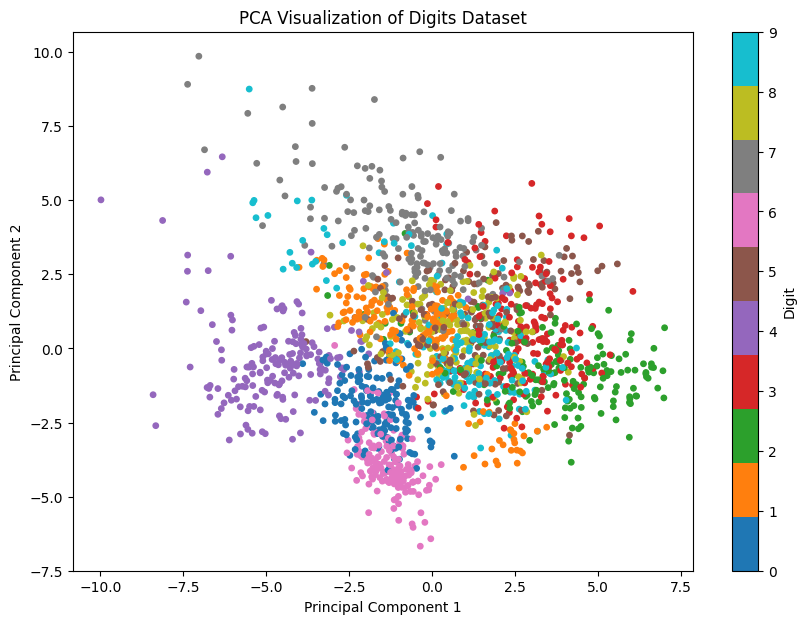

In [8]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="tab10",
    s=15
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Digits Dataset")

plt.colorbar(scatter, label="Digit")
plt.show()

In [9]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("t-SNE shape:", X_tsne.shape)

Original shape: (1797, 64)
t-SNE shape: (1797, 2)


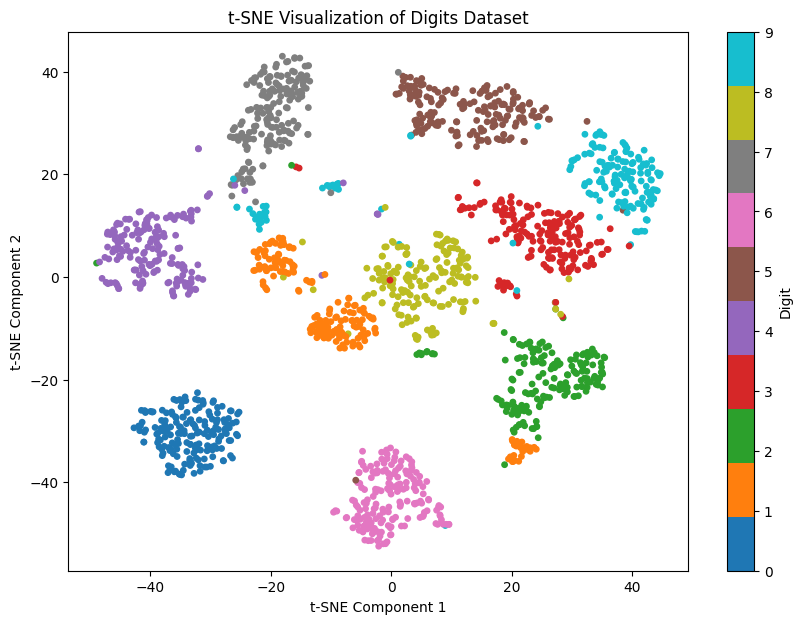

In [10]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=15
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Digits Dataset")

plt.colorbar(scatter, label="Digit")
plt.show()

In [11]:
print("""
Conclusion:
PCA and t-SNE are dimensionality reduction techniques used to represent
high-dimensional data in fewer dimensions.

PCA is a linear technique that finds directions of maximum variance,
while t-SNE is a non-linear technique that focuses on preserving local
relationships between data points.

Both techniques can be used to visualize complex datasets in 2D.
""")


Conclusion:
PCA and t-SNE are dimensionality reduction techniques used to represent
high-dimensional data in fewer dimensions.

PCA is a linear technique that finds directions of maximum variance,
while t-SNE is a non-linear technique that focuses on preserving local
relationships between data points.

Both techniques can be used to visualize complex datasets in 2D.

